- get experiment raw path
- load xml file
- load voltage data
- pull timestamps

-

In [157]:
import glob
import os
import h5py
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
from src import io

In [158]:
# get experiment raw path
# need os, glob
def get_base_path(experiment_id, raw = None, processed = None, base_dir = '/Volumes/AhmedLab/princess/data/'):
    # only one can be true
    experiment_id = str(experiment_id)
    if raw == True:
        experiment_path = glob.glob(os.path.join(base_dir, 'raw', f'*{experiment_id}'))[0]
    if processed == True:
        experiment_path = glob.glob(os.path.join(base_dir, 'processed', f'*{experiment_id}'))[0]

    return experiment_path


def load_voltage_data(experiment_path):
    """
    Loads voltage data and pulls out timestamps into arrays
    """
    file = glob.glob(os.path.join(experiment_path,'*.csv'))[0]
    data = pd.read_csv(file)

    # determine signal source by comparing average voltage from Carter's script
    # data.columns = data.columns.str.strip()
    # column_means = np.floor(data.mean())

    camera_timestamps = pull_timestamps_ms(data['Time(ms)'], data[' Input 2'], threshold=3)
    maui_timestamps = pull_timestamps_ms(data['Time(ms)'], data[' Input 1'], threshold=4)

    return camera_timestamps, maui_timestamps

def pull_timestamps_ms(time_array, signal_array, threshold):
    binarized_signal = []
    for signal in signal_array:
        if signal > threshold:
            binarized_signal.append(1)
        else:
            binarized_signal.append(0)

    # get frame starts by finding +1 changes
    # add [0] because diff loses the first value
    signal_changes = [0] + np.diff(binarized_signal)

    timestamps = []
    for i, val in enumerate(signal_changes):
        if val == 1:
            timestamps.append(time_array[i])

    return timestamps

def load_xml_timestamps(experiment_path):
    file = glob.glob(os.path.join(experiment_path,'*.xml'))[0]

    tree = ET.parse(file)
    root = tree.getroot()
    xml_frames = []
    for element in root.iter("Frame"):
        time = float(element.attrib['relativeTime'])
        xml_frames.append(time)

    xml_frames_ms = [x*1000 for x in xml_frames]
    return xml_frames_ms

In [161]:
raw_path = get_base_path(101, raw = True)
processed_path = get_base_path(101, processed = True)

# voltage_data = load_voltage_csv(raw_path)
camera_ttl_ms, maui_ttl_ms = load_voltage_data(raw_path)
xml_maui_timestamps = load_xml_timestamps(raw_path)

Text(0.5, 0, 'Time (ms)')

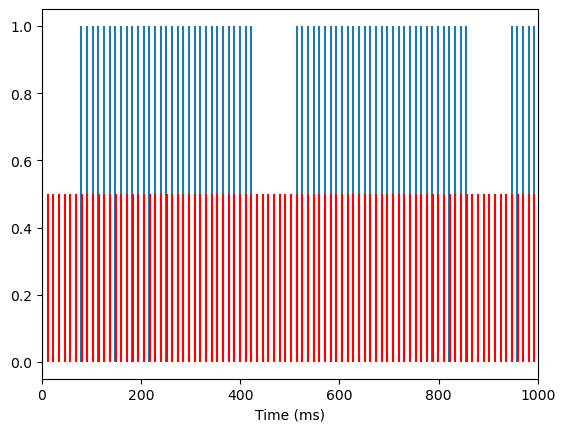

In [156]:
plt.vlines(xml_maui_timestamps, 0, 1, label='XML frames')
plt.vlines(maui_ttl_ms, 0, 0.5, colors='r', label='TTL frames')

plt.xlim(0,1000)
plt.xlabel('Time (ms)')

In [ ]:
# calculate volume rate + flyback times

In [ ]:
# remove ttls where there is no corresponding xml timestamp


In [ ]:
#